## Handwritten Digit Classifier
### The Problem

The goal of this project is to build a machine learning model capable of automatically identifying handwritten digits (0–9). While humans can easily read numbers written in different styles, computers perceive images only as grids of pixel intensities. The challenge lies in creating an algorithm robust enough to handle the high variance in human handwriting—such as different slants, thicknesses, and shapes—while maintaining high classification accuracy. Solving this problem is a foundational step in computer vision, with real-world applications ranging from bank check processing to automated postal mail sorting.

### Dataset

we are using the MNIST (Modified National Institute of Standards and Technology) dataset.

Size: It contains 70,000 grayscale images of handwritten digits.

Structure: The data is split into 60,000 training images and 10,000 test images.

In [1]:
# importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
import torch.nn as nn
from torchvision import datasets
import torch.nn.functional as F
from torchvision import transforms
import torch.optim as optim
from torch.utils.data import DataLoader

In [2]:
# configurating device
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
# importing datasets
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)



100%|██████████| 9.91M/9.91M [00:00<00:00, 14.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 342kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.03MB/s]


In [ ]:
# checking the range of values
data_min = train.data.min().item()
data_max = train.data.max().item()

print(f"Min value: {data_min}")
print(f"Max value: {data_max}")

Min value: 0
Max value: 255


In [ ]:
classes, counts = torch.unique(train.targets, return_counts=True)
print(classes, counts)
len(classes)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) tensor([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949])


10

In [ ]:
train.data.shape[1]*train.data.shape[2]

784

In [ ]:
train.data.shape

torch.Size([60000, 28, 28])

In [ ]:
test.data.shape

torch.Size([10000, 28, 28])

To see how the images look like, we can visualize a few samples from the dataset.

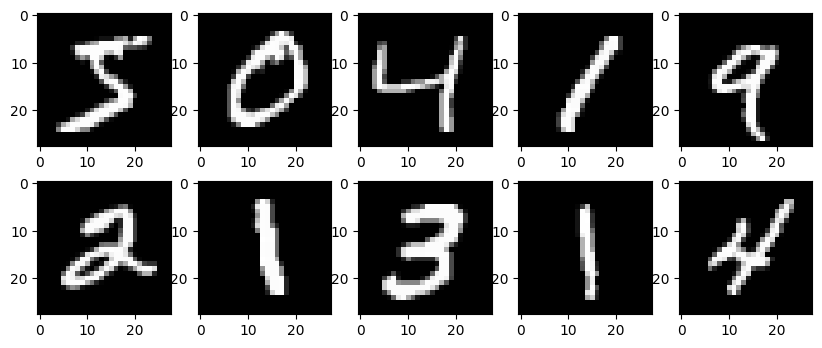

In [ ]:
# plotting examples of the images
def plot_examples(dataset, num_examples=10):

  plt.figure(figsize=(10, 4))
  for i in range(num_examples):
    plt.subplot(2, 5, i+1)
    plt.imshow(dataset[i][0].squeeze(), cmap='gray')

plot_examples(train)

To prepare the data for training, we use DataLoaders to organize the images into small batches.

In [4]:
# data loader
train_loader = DataLoader(train, batch_size=128, shuffle=True)
test_loader = DataLoader(test, batch_size= 128, shuffle= False )

### Multilayer Perceptron (MLP)

Next, we define the neural network architecture for training a Multilayer Perceptron (MLP). Since the images are
28
×
28
28×28 pixels, they are first flattened into a 784-dimensional vector so they can be processed by fully connected layers. The model then passes the input through two hidden layers with 256 and 128 neurons, each followed by a ReLU activation to introduce non-linearity. Finally, an output layer with 10 neurons produces scores for the ten possible digit classes (0–9)

In [ ]:
# nn architecutre
# 28*28 -> 256 -> 128 -> 10
class MLP(nn.Module):
  def __init__(self, inputs = train.data.shape[1]*train.data.shape[2], hiddens = [256, 128], output_classes= 10 ) -> None:
    super().__init__()
    self.layers = []
    self.layers.append(nn.Flatten())

    # add hidden layers
    current = inputs
    for hidden_dim in hiddens:
      self.layers.append(nn.Linear(current, hidden_dim))
      self.layers.append(nn.ReLU())
      current = hidden_dim

    # add output layers
    self.layers.append(nn.Linear(current, output_classes))
    # define steps
    self.model = nn.Sequential(*self.layers)

  def forward(self, x):
    return self.model(x)

In [ ]:
mlp = MLP()
total_parameters = sum(p.numel() for p in mlp.parameters())
print(f"Total number of parameters: {total_parameters}")

Total number of parameters: 235146


To train the model, we iterate through the dataset in small batches, comparing the model's predictions to the actual labels to calculate the error (loss). We then use backpropagation to trace that error backward and adjust the weights via the optimizer, gradually "tuning" the network to recognize the digits more accurately with each step.

In [5]:
# Function for training one epoch
def train_an_epoch(model, train_loader, criterion, optimizer, device):
  model.train() # set to training mode
  losses = 0.0
  # loop through the batches
  for batch in train_loader:
    inputs_features, labels = batch[0].to(device), batch[1].to(device)
    # reset gradient
    optimizer.zero_grad()
    # forward pass
    outputs = model(inputs_features)
    # compute loss
    loss = criterion(outputs, labels)
    # backpropagation
    loss.backward()
    # update weights
    optimizer.step()
    losses += loss.item() # add loss

  return losses / len(train_loader) # return average loss per this epoch

Now that we have the Training function ready, we should create a Validation function. This is critical because it tells you if your model is actually learning to recognize digits or if it’s just memorizing the training images (overfitting).

In [6]:
# Function for evaluating the accuracy of the MLP model
@torch.no_grad() # disable tracking gradient. This reduces memory consumption, and speed up testing computations
def evaluate(model, test_loader, criterion, device):
  model.eval() # set to evaluation mode
  total_samples = 0
  correct = 0 # number of correct predictions
  test_loss = 0
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    # foward pass
    outputs = model(inputs)
    # compute loss
    loss = criterion(outputs, labels)
    test_loss += loss.item()
    # predictions
    _, predicted = torch.max(outputs, 1)
    correct += (predicted == labels).sum().item()
    total_samples += labels.size(0)

  return test_loss / len(test_loader), correct / total_samples # return mean loss, and accuracy


Now that we have built the brain (the MLP) and the two primary skillsets (the Training and Evaluation functions), it is time to put everything into motion.

Next, we are going to write the Main orchestration Loop. This is the final piece of the puzzle that manages the entire lifecycle of the experiment: it defines how many times the model will see the data (Epochs), tracks the performance over time, and executes the training and validation back-to-back so you can watch your model "learn" in real-time.

Specifically, we will:

- Initialize the model, the Optimizer (the math that updates weights), and the Loss Function (the "ruler" that measures error).

- Run a train loop for a set number of epochs.


In [7]:
from google.colab import drive
drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/Deep_learning/datasets/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#  Device configuration (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_path = "best_mnist_model.pth" # directory for storing the best weights

mlp_model = MLP().to(device) # initialize the model
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001) # initialize the optimizer
criterion = nn.CrossEntropyLoss() # loss function
epochs_number = 10 # number of passes through the data
train_losses = []
test_losses = []
accuracy_evol = []
best_accuracy = 0.0  # Keep track of the highest score
for epoch in range(epochs_number):
  # training step
  train_loss = train_an_epoch(mlp_model, train_loader, criterion, optimizer, device)
  train_losses.append(train_loss)

  # evaluation step
  test_loss, accuracy = evaluate(mlp_model, test_loader, criterion, device)
  test_losses.append(test_loss)
  accuracy_evol.append(accuracy)
  if accuracy > best_accuracy:
        best_accuracy = accuracy
        # Save the "State Dict" (the learned weights)
        torch.save(mlp_model.state_dict(), folder_path + model_path)

  # progress report
  print(f"Epoch [{epoch+1}/{epochs_number}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Test Loss: {test_loss:.4f} "
        f"| Test Acc: {accuracy*100:.2f}%")

Epoch [1/10] | Train Loss: 0.3059 | Test Loss: 0.1615 | Test Acc: 94.85%
Epoch [2/10] | Train Loss: 0.1426 | Test Loss: 0.1585 | Test Acc: 94.78%
Epoch [3/10] | Train Loss: 0.1087 | Test Loss: 0.1303 | Test Acc: 95.84%
Epoch [4/10] | Train Loss: 0.0895 | Test Loss: 0.1079 | Test Acc: 96.80%
Epoch [5/10] | Train Loss: 0.0774 | Test Loss: 0.0869 | Test Acc: 97.40%
Epoch [6/10] | Train Loss: 0.0692 | Test Loss: 0.0825 | Test Acc: 97.52%
Epoch [7/10] | Train Loss: 0.0621 | Test Loss: 0.0917 | Test Acc: 97.30%
Epoch [8/10] | Train Loss: 0.0549 | Test Loss: 0.1031 | Test Acc: 97.16%
Epoch [9/10] | Train Loss: 0.0525 | Test Loss: 0.1131 | Test Acc: 96.83%
Epoch [10/10] | Train Loss: 0.0481 | Test Loss: 0.0902 | Test Acc: 97.56%


In [ ]:
# Re-initialize the model structure
best_model = MLP().to(device)

# Load the best weights from your Drive/Folder
best_model.load_state_dict(torch.load(folder_path + model_path))

best_model.eval()

# evaluate
final_test_loss, final_accuracy = evaluate(best_model, test_loader, criterion, device)

print(f"Final Performance of the BEST saved model: {final_accuracy*100:.2f}%")

Final Performance of the BEST saved model: 97.56%


In [8]:
def plot_loss_curve(train_losses, test_losses, accuracy_evolu):
  plt.figure(figsize=(12, 5))

  # Plot  Loss Curves
  plt.subplot(1, 2, 1)
  plt.plot(train_losses, label='Train Loss')
  plt.plot(test_losses, label='Test Loss')
  plt.title('Loss Over Epochs')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()

  # Plot  Accuracy Curve
  plt.subplot(1, 2, 2)
  plt.plot(accuracy_evol, label='Test Accuracy', color='green')
  plt.title('Validation Accuracy Over Epochs')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.grid(True)

  plt.tight_layout()
  plt.show()
plot_loss_curve(train_losses, test_losses, accuracy_evol)

The model learned quickly, hitting a strong 97.52% accuracy by the 6th epoch before hitting a performance ceiling (97.56%). The Test Loss after epoch 6 shows the model is starting to overfit, meaning it's beginning to memorize the training data rather than learning new patterns.

To see exactly where the model is tripping up, we’ll use a Confusion Matrix. This creates a grid where one axis is the True Label and the other is the Predicted Label, making it obvious if the model is, for example, constantly mistaking 4s for 9s.

In [ ]:
from sklearn.metrics import confusion_matrix

all_preds = []
all_labels = []

best_model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

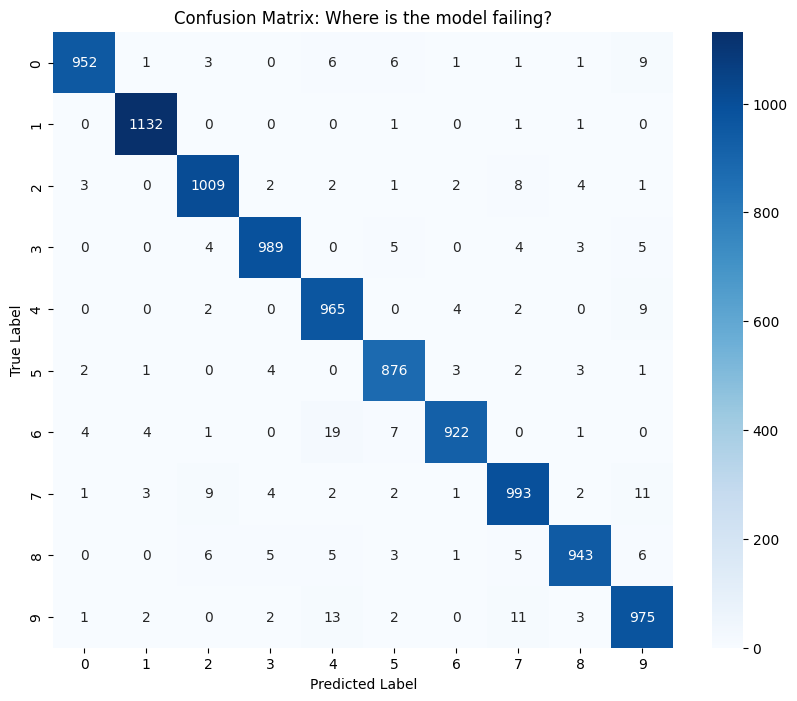

In [ ]:
# Compute the matrix
cm = confusion_matrix(all_labels, all_preds)

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Where is the model failing?')
plt.show()

The confusion matrix reveals that the model is frequently mistaking 9s for 4s or 7s. These errors, along with the classic 5 vs. 3 confusion, highlight the model's difficulty in distinguishing between digits that share nearly identical pixel patterns. Overall, the diagonal confirms high accuracy.

Let's plot few examples of wrongly classified images so that we can see some of the images where it got confused.

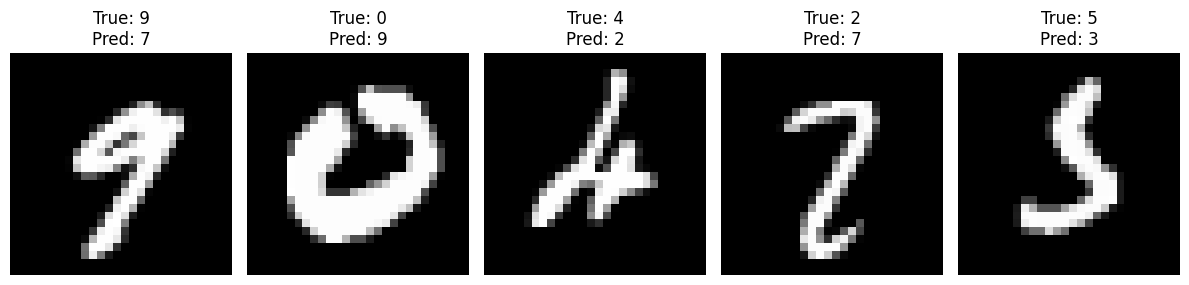

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

best_model.eval()
found_errors = []

#  Search for a few misclassified images
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, preds = torch.max(outputs, 1)

        # Find where prediction != actual label
        wrong_idx = (preds != labels).nonzero(as_tuple=True)[0]

        for idx in wrong_idx:
            found_errors.append({
                'img': images[idx].cpu(),
                'pred': preds[idx].item(),
                'actual': labels[idx].item()
            })

        if len(found_errors) >= 5: break # Stop once we have enough to show

#  Plot the results
plt.figure(figsize=(12, 4))
for i, error in enumerate(found_errors[:5]):
    plt.subplot(1, 5, i+1)
    # Reshape the 784 vector back to a 28x28 square for viewing
    plt.imshow(error['img'].view(28, 28), cmap='gray')
    plt.title(f"True: {error['actual']}\nPred: {error['pred']}")
    plt.axis('off')

plt.tight_layout()
plt.show()

The misclassified digits look visually similar, which shows the model learned some patterns but still struggles with ambiguous shapes.

The key reason is that an MLP treats the image as a flat vector of 784 pixels, ignoring how pixels are arranged in space. Because it cannot capture spatial features like edges, and local patterns, it sometimes confuses digits with similar pixel distributions.

While 97.56% is a fantastic result, there is still a small margin of error consisting of roughly 244 mistakes in 10,000 images. To bridge this gap, we can transition to a Convolutional Neural Network (CNN), which better preserves the 2D spatial relationships of the pixels compared to a flat MLP. Additionally, applying Data Augmentation—such as slight rotations or shifts—would help the model generalize better by teaching it to recognize digits even when they are off-center or tilted.

### Convolutional Neural Network (CNN)

In the next section, we build a CNN model to improve the above accuracy

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_model(nn.Module):
    def __init__(self, input_shape=(1, 28, 28), number_classes=10):
        super().__init__()

        self.convol_layer = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(4),
            nn.ReLU(),

            nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),

            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2), # Shape: (16, 14, 14)

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2), # Shape: (32, 7, 7)
        )

        # input_dim calculation
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            input_dim = self.convol_layer(dummy_input).view(1, -1).size(1)

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, number_classes)
        )

    def forward(self, x):
        # Ensure the input is the correct shape if needed
        conv_output = self.convol_layer(x)
        return self.fc_layers(conv_output)


In [12]:
# compute number of parameters
paratemeters = sum(p.numel() for p in CNN_model().parameters())
print(f"Total number of parameters: {paratemeters}")

Total number of parameters: 216386


Next, we train the model

In [10]:
import torch.optim as optim
#  Device configuration (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_path = "best_mnist_cnn_model.pth" # directory for storing the best weights

cnn_model = CNN_model().to(device) # initialize the model
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001) # initialize the optimizer
criterion = nn.CrossEntropyLoss() # loss function
epochs_number = 10 # number of passes through the data
train_losses = []
test_losses = []
accuracy_evol = []
best_accuracy = 0.0  # Keep track of the highest score
for epoch in range(epochs_number):
  # training step
  train_loss = train_an_epoch(cnn_model, train_loader, criterion, optimizer, device)
  train_losses.append(train_loss)

  # evaluation step
  test_loss, accuracy = evaluate(cnn_model, test_loader, criterion, device)
  test_losses.append(test_loss)
  accuracy_evol.append(accuracy)
  if accuracy > best_accuracy:
        best_accuracy = accuracy
        # Save the "State Dict" (the learned weights)
        torch.save(cnn_model.state_dict(), folder_path + model_path)

  # progress report
  print(f"Epoch [{epoch+1}/{epochs_number}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Test Loss: {test_loss:.4f} "
        f"| Test Acc: {accuracy*100:.2f}%")

Epoch [1/10] | Train Loss: 0.2695 | Test Loss: 0.0413 | Test Acc: 98.80%
Epoch [2/10] | Train Loss: 0.0678 | Test Loss: 0.0293 | Test Acc: 99.02%
Epoch [3/10] | Train Loss: 0.0467 | Test Loss: 0.0301 | Test Acc: 98.99%
Epoch [4/10] | Train Loss: 0.0389 | Test Loss: 0.0309 | Test Acc: 99.02%
Epoch [5/10] | Train Loss: 0.0314 | Test Loss: 0.0223 | Test Acc: 99.33%
Epoch [6/10] | Train Loss: 0.0286 | Test Loss: 0.0265 | Test Acc: 99.21%
Epoch [7/10] | Train Loss: 0.0249 | Test Loss: 0.0262 | Test Acc: 99.25%
Epoch [8/10] | Train Loss: 0.0203 | Test Loss: 0.0275 | Test Acc: 99.21%
Epoch [9/10] | Train Loss: 0.0189 | Test Loss: 0.0287 | Test Acc: 99.27%
Epoch [10/10] | Train Loss: 0.0170 | Test Loss: 0.0267 | Test Acc: 99.27%


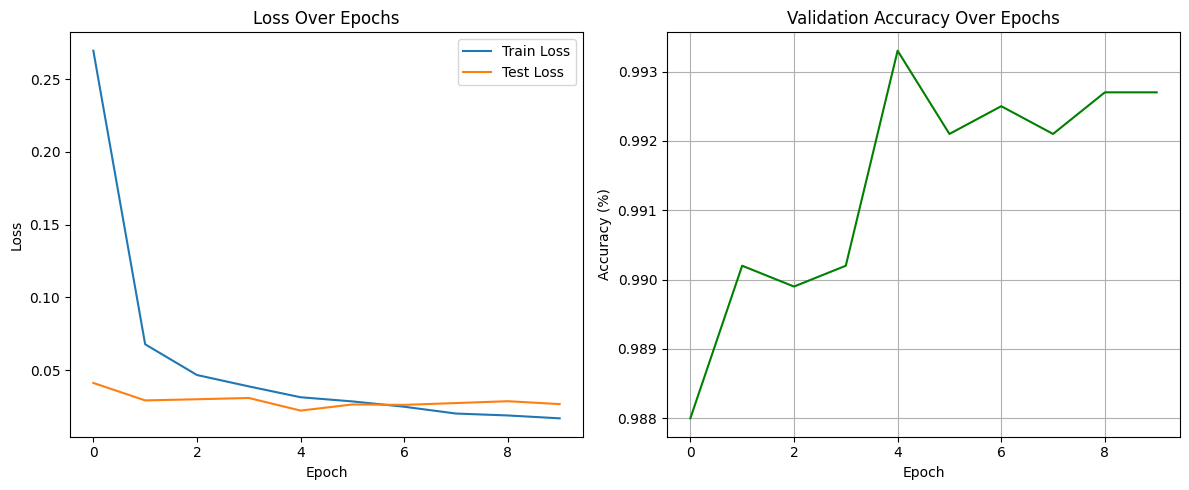

In [11]:
plot_loss_curve(train_losses, test_losses, accuracy_evol)

- The jump from 97.56% (previous best score of MLP) to 99.33% proves that the CNN’s spatial awareness is far more effective for image patterns than the MLP’s flat-vector approach.
- Performance stabilized after Epoch 5, indicating that the model has fully captured the MNIST complexity and further training would yield diminishing returns.

Final evaluation on test data using the best saved model

In [13]:
from sklearn.metrics import accuracy_score
import torch

#  Load weights
cnn_model.load_state_dict(torch.load(folder_path + model_path, map_location=device))

cnn_model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for inputs in test_loader:
        # Unpack and move to device
        images, labels = inputs[0].to(device), inputs[1].to(device)

        # Forward pass
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

Final Test Accuracy: 99.33%


In [14]:
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      1.00       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### Conclusion

- The CNN achieved a near-perfect 99.3% accuracy with remarkably balanced F1-scores ($\geq$ 0.99) across all digit classes, effectively eliminating the common confusion patterns seen in the previous MLP model. This performance demonstrates the robust feature extraction of convolutions and the successful regularization provided by Dropout and Batch Normalization